In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import fmatoolbox as fma
import ISRUtilities as isru
import xarray as xr
import scipy as sp
import pathlib
froot = pathlib.Path().cwd().parent.parent / 'Results/Figures/ISIntervals'
batch_file = '/mnt/hubel-data-103/Pietro/InfraSlowNRPaper/Data/IS_intervals.batch'
do_save = False

In [13]:
def _ISAPSD(session,regs=None,when='sleep.*#0',bin=0.05,nperseg=256):

    R = fma.regions.regions(session,phases=when,states=['sws','rem'],events='InfraSlowRhythm/infraslowaval')
    regs = R.ids if regs is None else np.array(regs)[np.isin(regs,R.ids)]
    isa = R.eventIntervals('slownr')

    window = bin
    fr = R.firingRate(regs=regs,window=window,when='sws')
    _, is_isa = fma.general.restrict(fr,isa,s_ind=True)
    #states = ['sws','rem','other']

    freq, psd_isa = sp.signal.welch(fr[is_isa,1:],fs=1/window,nperseg=nperseg,axis=0)
    _, psd_nisa = sp.signal.welch(fr[~is_isa,1:],fs=1/window,nperseg=nperseg,axis=0)

    psd = xr.DataArray([psd_isa,psd_nisa],dims=['isa','f','reg'],coords={'isa': [True,False], 'f': freq, 'reg': regs, 'rat': int(R.rat)})

    return psd


In [69]:
session = fma.data.readBatchFile(batch_file)[0][6]
print(session)
psd = _ISAPSD(session,bin=0.02,nperseg=2**11)

/mnt/hubel-data-131/perceval/Rat003_20231221/Rat003_20231221.xml


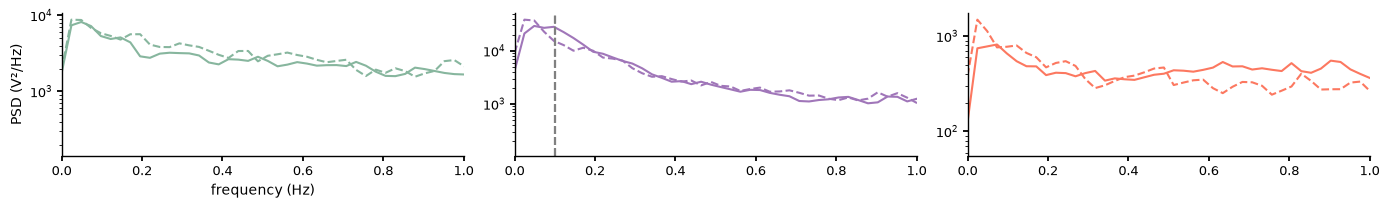

In [70]:
fig, ax = fma.plotting.makeFigure(size=(35,5),n=(1,3))
for i, reg in enumerate(psd.reg.values):
    ax[j].axvline(0.1,ls='--',color='gray')
    ax[i].semilogy(psd.f,psd.sel(reg=reg,isa=True),color=isru.paperColors(reg))
    ax[i].semilogy(psd.f,psd.sel(reg=reg,isa=False),ls='--',color=isru.paperColors(reg))
    ax[i].set_xlim([0,1])
ax[0].set(xlabel='frequency (Hz)',ylabel='PSD (V²/Hz)');

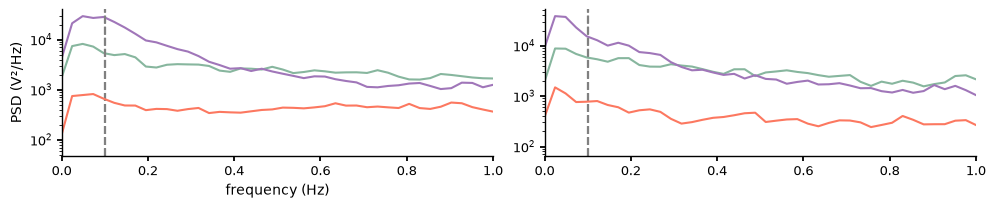

In [71]:
fig, ax = fma.plotting.makeFigure(size=(25,5),n=(1,2))
for i, reg in enumerate(psd.reg.values):
    for j, isa in enumerate([True,False]):
        ax[j].axvline(0.1,ls='--',color='gray')
        ax[j].semilogy(psd.f,psd.sel(reg=reg,isa=isa),color=isru.paperColors(reg))
        ax[j].set_xlim([0,1])

ax[0].set(xlabel='frequency (Hz)',ylabel='PSD (V²/Hz)');